# 10d — Human–Model Agreement by Model Group

Breaks down HM agreement by model group (VLM, VLM backbone decoder, standalone LLM, standalone LLM think)
with error bars showing within-group variance across questions.

Reads from the pair cache exported by nb10.

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

EXPORTS = Path('exports')

PRIMARY_METRIC = 'sbert_score_clip'   # main metric for HM analysis
ALL_METRICS    = ['exact_score', 'jaccard_score', 'rouge1_score', 'chrf_score',
                  'sbert_score_clip', 'simcse_score_clip', 'bertscore_f1']
SHORT_NAMES    = {
    'exact_score': 'exact', 'jaccard_score': 'jaccard',
    'rouge1_score': 'rouge1', 'chrf_score': 'chrf',
    'sbert_score_clip': 'sbert', 'simcse_score_clip': 'simcse',
    'bertscore_f1': 'bertscore',
}
VARIANT_ORDER  = ['C', 'B', 'A']
PAIR_TYPES     = ['HH', 'MM', 'HM']

GROUP_ORDER  = ['VLM', 'VLM backbone decoder', 'standalone LLM', 'standalone LLM (think)']
GROUP_COLORS = {
    'HH':                      '#222222',
    'MM':                      '#9E9E9E',
    'VLM':                     '#1565C0',
    'VLM backbone decoder':    '#42A5F5',
    'standalone LLM':          '#E65100',
    'standalone LLM (think)':  '#FF8F00',
}

In [24]:
# ── Load pair cache ───────────────────────────────────────────────────────────
pairs = pd.read_parquet(EXPORTS / 'pair_cache.parquet')

avail_metrics = [c for c in ALL_METRICS if c in pairs.columns]
for col in avail_metrics:
    pairs[SHORT_NAMES[col]] = pairs[col]

short_avail = [SHORT_NAMES[c] for c in avail_metrics]

print(f'Pairs: {len(pairs):,}  |  Metrics: {short_avail}')
print(f'Pair types: {pairs["pair_type"].value_counts().to_dict()}')
print(f'Variants:   {pairs["variant"].value_counts().to_dict()}')
print(f'\nSubject groups:')
grp_counts = pd.concat([
    pairs[["subject_1", "subject_group_1"]].rename(columns={"subject_1": "s", "subject_group_1": "g"}),
    pairs[["subject_2", "subject_group_2"]].rename(columns={"subject_2": "s", "subject_group_2": "g"}),
]).drop_duplicates()
print(grp_counts['g'].value_counts().to_string())

Pairs: 434,950  |  Metrics: ['exact', 'jaccard', 'rouge1', 'chrf', 'sbert', 'simcse', 'bertscore']
Pair types: {'HM': 208116, 'HH': 166320, 'MM': 60514}
Variants:   {'B': 145251, 'C': 145199, 'A': 144500}

Subject groups:
g
human                     36
standalone LLM             9
VLM                        7
standalone LLM (think)     5
VLM backbone decoder       3


In [25]:
# ── Per-question HM mean by model group (variant C, primary metric) ───────────
# For HM pairs, subject_1=human, subject_2=model (normalised in nb10 cell 17).
hm = pairs[(pairs['pair_type'] == 'HM') & (pairs['variant'] == 'C')].copy()
hm['model_group'] = hm['subject_group_2']

# Per-question per-group mean
q_group = (
    hm.groupby(['question_id', 'model_group'])['sbert']
    .mean()
    .reset_index()
    .rename(columns={'sbert': 'hm_mean'})
)

# HH reference per question
hh_q = (
    pairs[(pairs['pair_type'] == 'HH') & (pairs['variant'] == 'C')]
    .groupby('question_id')['sbert']
    .mean()
    .rename('hh_mean')
    .reset_index()
)
# MM reference per question
mm_q = (
    pairs[(pairs['pair_type'] == 'MM') & (pairs['variant'] == 'C')]
    .groupby('question_id')['sbert']
    .mean()
    .rename('mm_mean')
    .reset_index()
)

q_group = q_group.merge(hh_q, on='question_id', how='left')
q_group = q_group.merge(mm_q, on='question_id', how='left')
q_group['gap_to_hh'] = q_group['hh_mean'] - q_group['hm_mean']

print('Per-question HM mean by group (variant C, SBERT):')
summary = (
    q_group.groupby('model_group')['hm_mean']
    .agg(['mean', 'std', 'count'])
    .reindex([g for g in GROUP_ORDER if g in q_group['model_group'].unique()])
    .round(3)
)
summary['hh_ref'] = hh_q['hh_mean'].mean().round(3)
summary['gap_to_hh'] = (summary['hh_ref'] - summary['mean']).round(3)
print(summary.to_string())

Per-question HM mean by group (variant C, SBERT):
                         mean    std  count  hh_ref  gap_to_hh
model_group                                                   
VLM                     0.479  0.155     88   0.512      0.033
VLM backbone decoder    0.511  0.168     88   0.512      0.001
standalone LLM          0.394  0.129     88   0.512      0.118
standalone LLM (think)  0.403  0.139     88   0.512      0.109


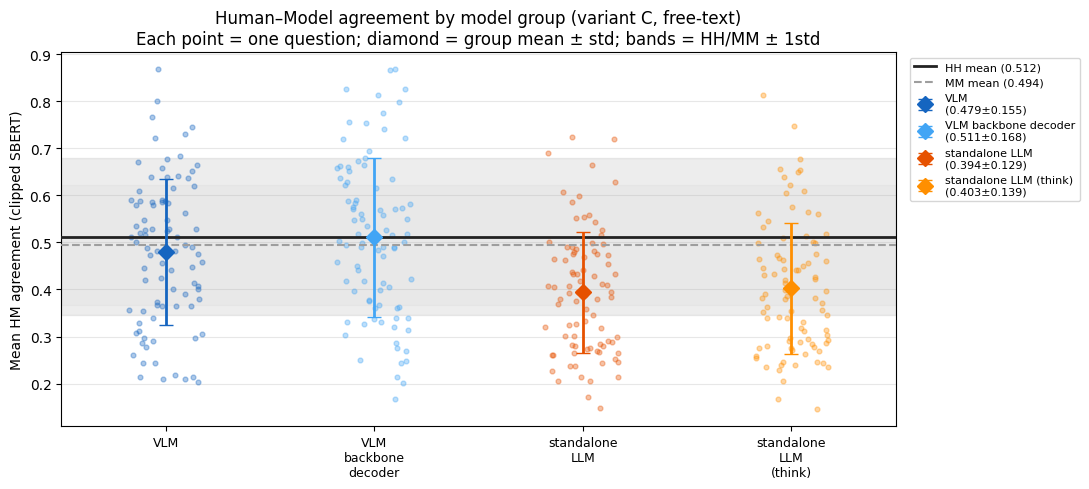

In [26]:
# ── Plot 1: per-question scatter with error bars, grouped ────────────────────
# Each group = one cluster of points (questions). Error bars = ±1 std across questions.
# HH and MM shown as horizontal reference bands.

groups_present = [g for g in GROUP_ORDER if g in q_group['model_group'].unique()]

fig, ax = plt.subplots(figsize=(11, 5))

# HH reference band
hh_mean = hh_q['hh_mean'].mean()
hh_std  = hh_q['hh_mean'].std()
ax.axhline(hh_mean, color=GROUP_COLORS['HH'], lw=2, ls='-', label=f'HH mean ({hh_mean:.3f})', zorder=5)
ax.axhspan(hh_mean - hh_std, hh_mean + hh_std, color=GROUP_COLORS['HH'], alpha=0.08)

# MM reference band
mm_mean = mm_q['mm_mean'].mean()
mm_std  = mm_q['mm_mean'].std()
ax.axhline(mm_mean, color=GROUP_COLORS['MM'], lw=1.5, ls='--', label=f'MM mean ({mm_mean:.3f})', zorder=5)
ax.axhspan(mm_mean - mm_std, mm_mean + mm_std, color=GROUP_COLORS['MM'], alpha=0.06)

# HM by group: jitter + mean ± std
x_ticks, x_labels = [], []
for xi, grp in enumerate(groups_present):
    sub = q_group[q_group['model_group'] == grp]['hm_mean'].dropna()
    color = GROUP_COLORS.get(grp, '#555')
    jitter = np.random.uniform(-0.18, 0.18, size=len(sub))
    ax.scatter(xi + jitter, sub, s=12, alpha=0.35, color=color, zorder=3)
    ax.errorbar(xi, sub.mean(), yerr=sub.std(), fmt='D', color=color,
                ms=8, lw=2, capsize=5, zorder=6,
                label=f'{grp}\n({sub.mean():.3f}±{sub.std():.3f})')
    x_ticks.append(xi)
    x_labels.append(grp.replace(' ', '\n'))

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Mean HM agreement (clipped SBERT)')
ax.set_title('Human–Model agreement by model group (variant C, free-text)\n'
             'Each point = one question; diamond = group mean ± std; bands = HH/MM ± 1std')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(-0.5, len(groups_present) - 0.5)
plt.tight_layout()
plt.show()

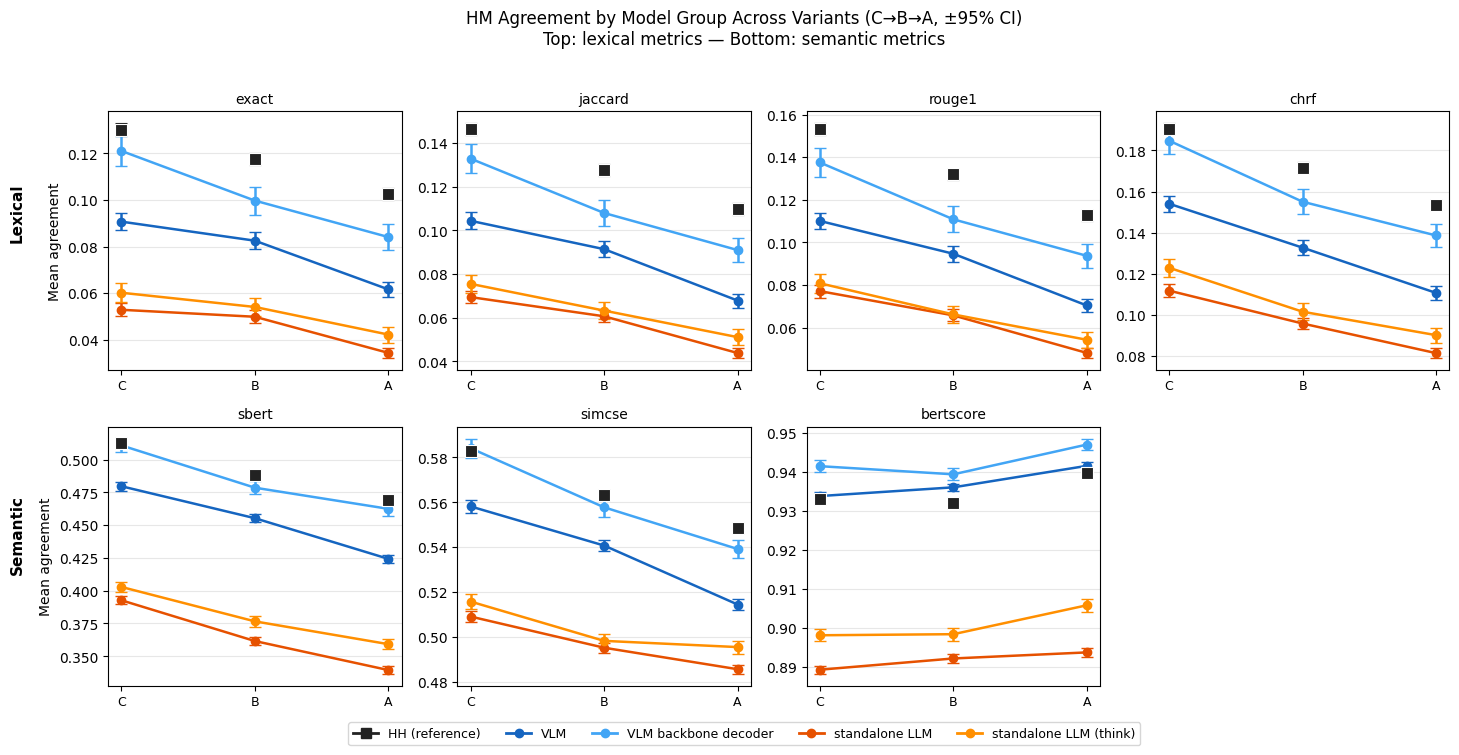

In [29]:
# ── Plot 2: across variants — group means with CI (lexical / semantic rows) ────
# Layout mirrors nb10c score-distribution plot:
#   Row 0: lexical metrics  (exact, jaccard, rouge1, chrf)
#   Row 1: semantic metrics (sbert, simcse, bertscore)
#   Colors = model group;  HH shown as black square per variant.
#   Legend: horizontal bar at the bottom of the figure.

LEX_METRICS = [m for m in short_avail if m in ('exact', 'jaccard', 'rouge1', 'chrf')]
SEM_METRICS = [m for m in short_avail if m in ('sbert', 'simcse', 'bertscore')]

n_cols = max(len(LEX_METRICS), len(SEM_METRICS))
x = np.arange(len(VARIANT_ORDER))

fig, axes = plt.subplots(2, n_cols,
                         figsize=(3.6 * n_cols, 7),
                         sharey=False)

def plot_variant_row(axes_row, metrics):
    for ax, metric in zip(axes_row, metrics):
        # HH reference per variant
        for vi, var in enumerate(VARIANT_ORDER):
            hh_v = pairs[(pairs['pair_type'] == 'HH') & (pairs['variant'] == var)][metric]
            ax.errorbar(vi, hh_v.mean(), yerr=hh_v.sem() * 1.96,
                        fmt='s', color=GROUP_COLORS['HH'],
                        ms=8, lw=2, capsize=4,
                        label='HH' if var == 'C' else '',
                        zorder=6, markeredgecolor='white', markeredgewidth=0.8)

        # HM by group per variant
        for grp in groups_present:
            color = GROUP_COLORS.get(grp, '#555')
            means, cis = [], []
            for var in VARIANT_ORDER:
                sub = pairs[
                    (pairs['pair_type'] == 'HM') &
                    (pairs['variant'] == var) &
                    (pairs['subject_group_2'] == grp)
                ][metric]
                means.append(sub.mean())
                cis.append(sub.sem() * 1.96)
            ax.errorbar(x, means, yerr=cis, fmt='o-',
                        color=color, ms=6, lw=1.8, capsize=4,
                        label=grp, zorder=5)

        ax.set_xticks(x)
        ax.set_xticklabels(['C', 'B', 'A'], fontsize=9)
        ax.set_title(metric, fontsize=10)
        ax.grid(axis='y', alpha=0.3)

    # Hide unused axes in this row
    for ax in axes_row[len(metrics):]:
        ax.set_visible(False)

# Row 0: lexical
axes[0, 0].set_ylabel('Mean agreement')
plot_variant_row(axes[0], LEX_METRICS)
fig.text(-0.01, 0.73, 'Lexical', va='center', rotation='vertical',
         fontsize=11, fontweight='bold')

# Row 1: semantic
axes[1, 0].set_ylabel('Mean agreement')
plot_variant_row(axes[1], SEM_METRICS)
fig.text(-0.01, 0.27, 'Semantic', va='center', rotation='vertical',
         fontsize=11, fontweight='bold')

plt.suptitle('HM Agreement by Model Group Across Variants (C→B→A, ±95% CI)\n'
             'Top: lexical metrics — Bottom: semantic metrics',
             y=1.02, fontsize=12)
plt.tight_layout()

# Horizontal legend anchored below the figure
from matplotlib.lines import Line2D
legend_handles = (
    [Line2D([0],[0], color=GROUP_COLORS['HH'], marker='s', lw=2, ms=7, label='HH (reference)')] +
    [Line2D([0],[0], color=GROUP_COLORS.get(g, '#555'), marker='o', lw=2, ms=6, label=g)
     for g in groups_present]
)
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04),
           ncol=len(legend_handles),
           fontsize=9,
           frameon=True)

plt.show()

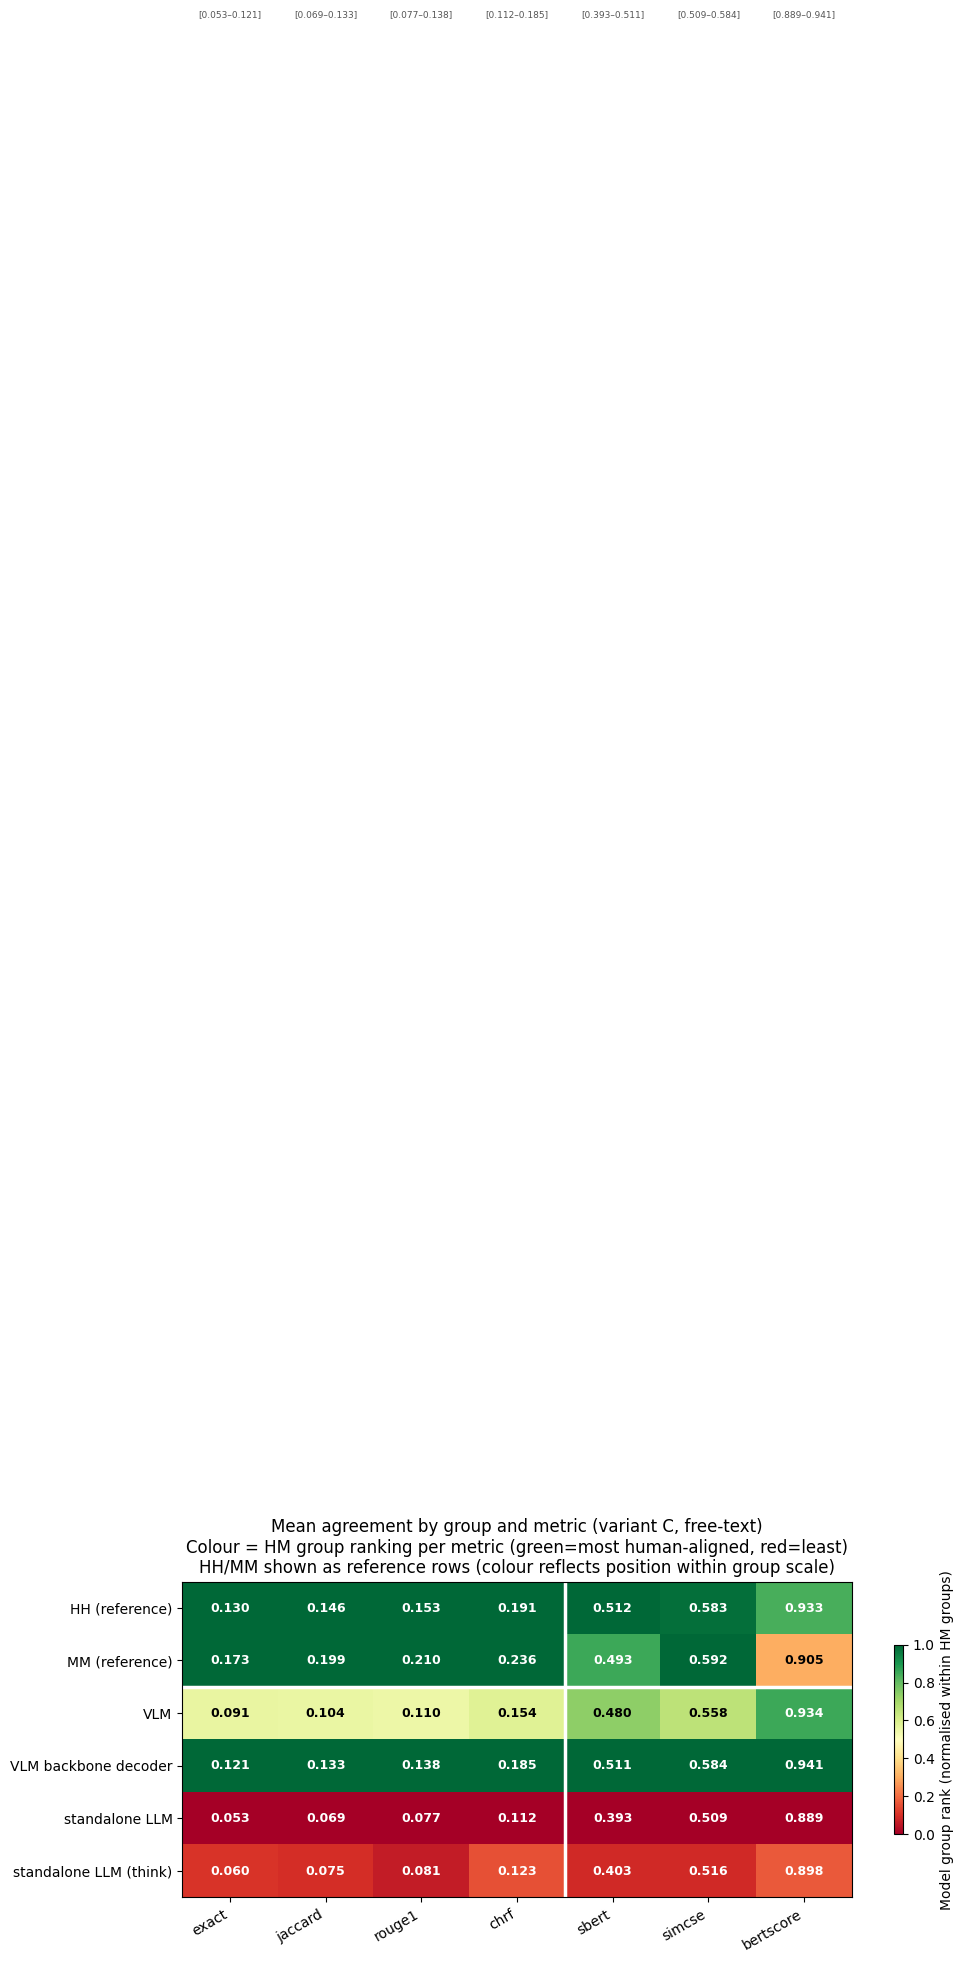

,exact,jaccard,rouge1,chrf,sbert,simcse,bertscore
HH (reference),0.130,0.146,0.153,0.191,0.512,0.583,0.933
MM (reference),0.173,0.199,0.210,0.236,0.493,0.592,0.905
VLM,0.091,0.104,0.110,0.154,0.480,0.558,0.934
VLM backbone decoder,0.121,0.133,0.138,0.185,0.511,0.584,0.941
standalone LLM,0.053,0.069,0.077,0.112,0.393,0.509,0.889
standalone LLM (think),0.060,0.075,0.081,0.123,0.403,0.516,0.898


In [28]:
# ── Plot 3: all metrics × all groups (heatmap) ───────────────────────────────
# Rows = model groups + HH/MM references. Columns = metrics.
# Colour normalised per column using HM group rows only —
# so green/red reflects model group ranking, not distance from HH/MM.

lex  = [m for m in short_avail if m in ('exact', 'jaccard', 'rouge1', 'chrf')]
sem  = [m for m in short_avail if m in ('sbert', 'simcse', 'bertscore')]
col_order = lex + sem

C_pairs = pairs[pairs['variant'] == 'C']

# Build rows: HH/MM first (references), then HM groups
ref_labels, ref_data = [], []
ref_labels.append('HH (reference)')
ref_data.append([C_pairs[C_pairs['pair_type'] == 'HH'][m].mean() for m in col_order])
ref_labels.append('MM (reference)')
ref_data.append([C_pairs[C_pairs['pair_type'] == 'MM'][m].mean() for m in col_order])

grp_labels, grp_data = [], []
for grp in groups_present:
    grp_pairs = C_pairs[(C_pairs['pair_type'] == 'HM') & (C_pairs['subject_group_2'] == grp)]
    grp_labels.append(grp)
    grp_data.append([grp_pairs[m].mean() for m in col_order])

all_labels = ref_labels + grp_labels
heat = pd.DataFrame(ref_data + grp_data, index=all_labels, columns=col_order)

# ── Normalise per column using only HM group rows ────────────────────────────
ref_vals = np.array(ref_data, dtype=float)   # shape (n_refs, n_cols)
grp_vals = np.array(grp_data, dtype=float)   # shape (n_groups, n_cols)
all_vals = heat.values.astype(float)

col_min   = np.nanmin(grp_vals, axis=0, keepdims=True)
col_max   = np.nanmax(grp_vals, axis=0, keepdims=True)
col_range = col_max - col_min
col_range[col_range == 0] = 1.0

# Normalise all rows using group min/max (refs may fall outside [0,1] — clip for display)
norm_vals = np.clip((all_vals - col_min) / col_range, -0.1, 1.1)

fig, ax = plt.subplots(figsize=(len(col_order) * 1.4 + 1, len(all_labels) * 0.55 + 0.8))
im = ax.imshow(norm_vals, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(col_order, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(all_labels)))
ax.set_yticklabels(all_labels, fontsize=10)

# Annotate with raw values
for i in range(len(all_labels)):
    for j in range(len(col_order)):
        val = all_vals[i, j]
        nv  = np.clip(norm_vals[i, j], 0, 1)
        txt_color = 'white' if (nv < 0.25 or nv > 0.80) else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, color=txt_color, fontweight='bold')

# Separator between reference rows and group rows
ax.axhline(len(ref_labels) - 0.5, color='white', lw=2.5)
# Separator between lexical and semantic columns
ax.axvline(len(lex) - 0.5, color='white', lw=2.5)

# Column range (from group rows only)
for j, col in enumerate(col_order):
    lo, hi = col_min[0, j], col_max[0, j]
    ax.text(j, len(all_labels) - 0.05, f'[{lo:.3f}–{hi:.3f}]',
            ha='center', va='bottom', fontsize=6.5, color='#555',
            transform=ax.get_xaxis_transform())

plt.colorbar(im, ax=ax, shrink=0.6, label='Model group rank (normalised within HM groups)')
ax.set_title('Mean agreement by group and metric (variant C, free-text)\n'
             'Colour = HM group ranking per metric (green=most human-aligned, red=least)\n'
             'HH/MM shown as reference rows (colour reflects position within group scale)')
plt.tight_layout()
plt.show()

display(heat.round(3))